# Acces ABoVE LVISF2 Level 3 gridded data at ORNL DAAC on s3

`LVISF2` at ORNL DAAC AWS buckets 

Paul Montesano, PhD

#### Note:  
 - this shows you how to access raster data on s3 and to plot/analyze the data without downloading it

In [16]:
!pip install -U contextily

  Using cached contextily-1.6.2-py3-none-any.whl.metadata (2.9 kB)
Using cached contextily-1.6.2-py3-none-any.whl (17 kB)


In [1]:
import s3fs
import os
import boto3
import pandas as pd
import geopandas as gpd

import rasterio
import requests
import glob

import rasterio as rio
from rasterio.windows import Window

In [ ]:
import sys
sys.path.append('/projects/code/icesat2_boreal/lib')
sys.path.append('/projects/code/geoscitools')
import footprintlib
import maplib
import CovariateUtils


In [17]:
import contextily as ctx

In [ ]:
#from mpl_toolkits.basemap import Basemap

## Access to EarthData s3 bucket 

https://github.com/nasa/EMIT-Data-Resources/blob/main/python/how-tos/How_to_Direct_S3_Access.ipynb

In [2]:
s3_cred_endpoint = {
    'podaac':   'https://archive.podaac.earthdata.nasa.gov/s3credentials',
    'gesdisc':  'https://data.gesdisc.earthdata.nasa.gov/s3credentials',
    'lpdaac':   'https://data.lpdaac.earthdatacloud.nasa.gov/s3credentials',
    'ornldaac': 'https://data.ornldaac.earthdata.nasa.gov/s3credentials',
    'ghrcdaac': 'https://data.ghrc.earthdata.nasa.gov/s3credentials'
}

In [3]:
# Define Function 
def get_temp_creds(provider):
    return requests.get(s3_cred_endpoint[provider]).json()

### Datasets at EarthDataCloud
 - LVIS Gridded: `C2264350397-ORNL_CLOUD` https://cmr.earthdata.nasa.gov/search/concepts/C2264350397-ORNL_CLOUD.html

In [4]:
DICT_LVIS = {
                'AWS_SESSION':    None,
                'REFERENCE':     'https://daac.ornl.gov/cgi-bin/dataset_lister.pl?p=34',
                'BUCKET' :       'ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure', 
                'FILES_LIST':     None,
                'RASTER_BUCKET': 'ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data',
                'SEARCHKEY':      None,
                'SEARCHEXT':     '.tif',
                'RASTER_LIST':    None
                }

In [5]:
LVIS_GRID_ATTRIBUTE = 'RH098_mean_30m' #'CC_gte_01p37' 'cnt' 'COMPLEXITY'

In [6]:
# Get Credentials
temp_creds_req = get_temp_creds('ornldaac')

# Pass Authentication to s3fs
s3_ornl = s3fs.S3FileSystem(anon=False, key=temp_creds_req['accessKeyId'], secret=temp_creds_req['secretAccessKey'], token=temp_creds_req['sessionToken'])

In [7]:
DICT_LVIS['SEARCHKEY'] = f'*{LVIS_GRID_ATTRIBUTE}'
DICT_LVIS['AWS_SESSION'] = s3_ornl

In [8]:
if False: # attempt to look for geopackage
    DICT_LVIS['RASTER_BUCKET'] = 'ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure'
    DICT_LVIS['SEARCHKEY'] = ''
    DICT_LVIS['SEARCHEXT'] = '.gkpg'
    DICT_LVIS['AWS_SESSION'] = s3_ornl

In [9]:
ORNL_AWS_DATA_DICT_LIST = [
            DICT_LVIS,
]

## Loop to access various datasets on s3
 - print # of files
 - created `UPDATED_AWS_DATA_DICT_LIST` that has the FULL set of rasters returned from your search

In [10]:
%%time

UPDATED_AWS_DATA_DICT_LIST = []

for idx, d in enumerate(ORNL_AWS_DATA_DICT_LIST):  # Just for Gridded LVIS access
    
    # Get dataset-specific s3 session
    s3 = d['AWS_SESSION']
    
    bucket = d['BUCKET']
    searchkey = d['SEARCHKEY'] 
    searchext = d['SEARCHEXT']
    
    print(f"AWS dataset {idx+1:02} main bucket: {bucket} from {d['REFERENCE']}")
    
    print(f"# of files in {bucket}: {len(s3.glob(bucket + '/*')) }")
    
    # Update dict with a list of all files
    d.update( {'FILES_LIST': [i.replace(bucket, 's3://'+bucket) for i in s3.glob(os.path.join(bucket + '/*'))] })
    
    # Update dict with a list of all raster files if raster are in a separate bucket
    if not d['RASTER_BUCKET'] == bucket:
        bucket = d['RASTER_BUCKET']
    print(os.path.join(bucket, f'{searchkey}*{searchext}'))
    s3_f_list = s3.glob(os.path.join(bucket, f'{searchkey}*{searchext}') )
    
    # Update dict with a list of all files
    d.update( {'RASTER_LIST': [i.replace(bucket, 's3://'+bucket) for i in s3_f_list] })
    UPDATED_AWS_DATA_DICT_LIST.append(d)
    
    print(f"# of raster files in {d['RASTER_BUCKET']}: {len( d['RASTER_LIST'] )}")
    
    n=20
    print(f'Showing first {n}...')
    [print(file) for file in s3_f_list[0:n]]
    print('\n')

AWS dataset 01 main bucket: ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure from https://daac.ornl.gov/cgi-bin/dataset_lister.pl?p=34
# of files in ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure: 1
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/*RH098_mean_30m*.tif
# of raster files in ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data: 3579
Showing first 20...
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_056233_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_056593_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_057198_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_057748_RH098_mean_30m.tif
ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructur

### Quick check and download for use in R mapping notebook

In [11]:
# s3_data_url = 's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_062193_CC_gte_01p37m_30m.tif'
# with rasterio.open(d['AWS_SESSION'].open(s3_data_url, mode='rb')) as src:
#     print(src.profile)
d['RASTER_LIST'][100]

's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_RH098_mean_30m.tif'

In [12]:
fn_list = [d['RASTER_LIST'][100], d['RASTER_LIST'][812], d['RASTER_LIST'][450],  d['RASTER_LIST'][700]]
fn_list

['s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_RH098_mean_30m.tif',
 's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0714_R1803_097961_RH098_mean_30m.tif',
 's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0703_R1803_086290_RH098_mean_30m.tif',
 's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0714_R1803_080954_RH098_mean_30m.tif']

In [183]:
import matplotlib.pyplot as plt
import math
import rasterio
from rasterio.plot import show_hist, show

In [224]:
# Determine the grid size
n_facets = len(fn_list)
cols = 2  # Number of columns in the grid
rows = math.ceil(n_facets / cols)

s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_CC_gte_01p37m_30m.tif
s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0714_R1803_097961_CC_gte_01p37m_30m.tif
s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0703_R1803_086290_CC_gte_01p37m_30m.tif
s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0714_R1803_080954_CC_gte_01p37m_30m.tif


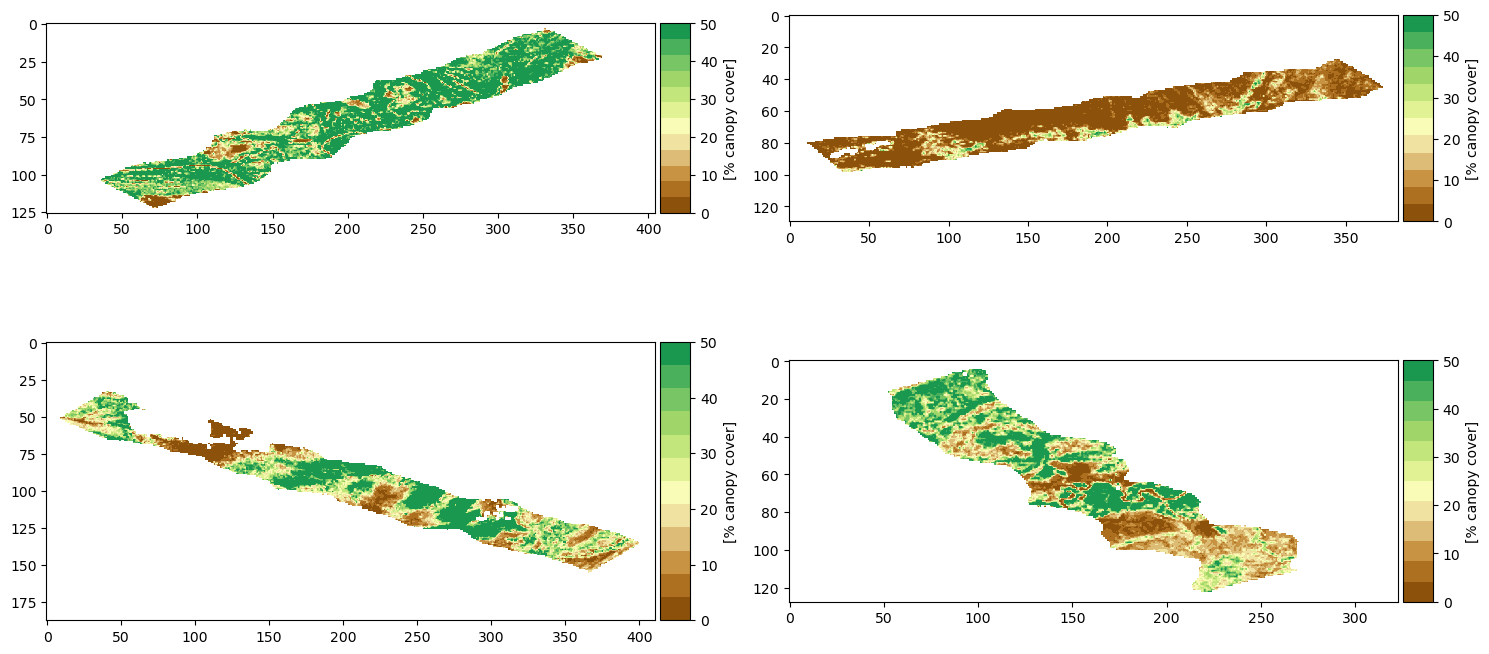

In [234]:
# Create a grid of subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=False, sharey=False)
axes = axes.flatten()  # Flatten in case we have a 2D array of axes
SF_LIST = [1e-2 for f in fn_list]

for i, species in enumerate(fn_list):
    
    fn = fn_list[i]
    plot_from_daac(aws_session=d['AWS_SESSION'], s3_data_url=fn, ax=axes[i], SCALE_FACTOR = SF_LIST[i], MAX_VAL=50, LEGEND_TEXT = '[% canopy cover]')

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [99]:
for fn in fn_list:
    s3.download(fn, '/projects/my-public-bucket/lvis_flightlines')

### Find Topo tiles that intersect

In [68]:
import rasterio
import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

# Step 1: Read the raster file
raster_path = "/projects/my-public-bucket/lvis_flightlines/LVISF3_ABoVE2017_0629_R1803_094195_RH098_mean_30m.tif"
with rasterio.open(raster_path) as src:
    # Get the raster metadata
    raster_crs = src.crs
    
    # Get the bounds in the raster's CRS
    raster_bounds = src.bounds
    print(f"Raster bounds (in raster CRS): {raster_bounds}")
    
    # Create a polygon from the bounds (bounding box)
    raster_bbox = box(*raster_bounds)
    
    # Create a GeoDataFrame from the bbox
    raster_bbox_gdf = gpd.GeoDataFrame(
        {'geometry': [raster_bbox]}, 
        crs=raster_crs
    )
    
    # Read band 1 for visualization (optional)
    raster_data = src.read(1)

raster_bbox_gdf.explore()

Raster bounds (in raster CRS): BoundingBox(left=-909660.0, bottom=2489270.0, right=-898710.0, top=2494670.0)


In [73]:
import fiona

# Step 2: Read the GeoPackage
gpkg_path = "/projects/my-public-bucket/DPS_tile_lists/run_build_stack_topo/build_stack_v2024_2/CopernicusGLO30/Topo_tindex_master.gpkg"

# List all layers in the GeoPackage
available_layers = fiona.listlayers(gpkg_path)
print(f"Available layers in GeoPackage: {available_layers}")

# Choose a layer to process (using first layer as example)
layer_name = available_layers[0]  # Change this if you want a different layer

# Read the GeoPackage layer
gdf = gpd.read_file(gpkg_path, layer=layer_name)
print(f"GeoPackage CRS: {gdf.crs}")
print(f"Number of features in GeoPackage: {len(gdf)}")

# Step 3: Make sure both datasets are in the same CRS
if raster_bbox_gdf.crs != gdf.crs:
    print("Reprojecting raster bounding box to match GeoPackage CRS...")
    raster_bbox_gdf = raster_bbox_gdf.to_crs(gdf.crs)
    print(f"Reprojected bounding box CRS: {raster_bbox_gdf.crs}")

# Step 4: Find polygons that intersect with the raster's extent
intersecting_polygons = gdf[gdf.intersects(raster_bbox_gdf.geometry.iloc[0])]

#intersecting_polygons.explore()

Available layers in GeoPackage: ['Topo_tindex_master']
GeoPackage CRS: PROJCS["unnamed",GEOGCS["GRS 1980(IUGG, 1980)",DATUM["unknown",SPHEROID["GRS80",6378137,298.257222101],TOWGS84[0,0,0,0,0,0,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["standard_parallel_1",50],PARAMETER["standard_parallel_2",70],PARAMETER["latitude_of_center",40],PARAMETER["longitude_of_center",180],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Number of features in GeoPackage: 5197


In [72]:
import merge_neighbors_atl08

In [79]:
tile_list = merge_neighbors_atl08.get_neighbors(gdf, 'tile_num', intersecting_polygons.tile_num.iloc[0]) + [intersecting_polygons.tile_num.iloc[0]]
tile_list

[2679, 2680, 2520, 2681, 2599, 2518, 2601, 2519, 2600]

### Plot an LVIS grid using its s3 url associated with the ORNL DAAC bucket

In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize

In [19]:
# CHM cmap
forest_ht_cmap = LinearSegmentedColormap.from_list('forest_ht', ['#636363','#fc8d59','#fee08b','#ffffbf','#d9ef8b','#91cf60','#1a9850','#005a32'], 12)

# CC cmap
forest_cover_cmap = LinearSegmentedColormap.from_list('forest_cover', ['#8c510a','#bf812d','#dfc27d','#ffffbf','#d9ef8b','#a6d96a','#66bd63','#1a9850'], 12)

In [20]:
from rasterio.plot import show, show_hist
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.enums import Resampling as RioResampling

import contextily as ctx

import numpy as np

def reproject_and_mask(src, dst_crs = 'EPSG:4326'):
    
    # Read metadata
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })
    
    # Prepare destination array
    destination = np.empty((height, width), dtype=src.meta['dtype'])
    
    # Reproject
    reproject(
        source=rasterio.band(src, 1),
        destination=destination,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=transform,
        dst_crs=dst_crs,
        resampling=Resampling.nearest
    )
    
    # Mask nodata
    nodata = src.nodata
    if nodata is not None:
        masked = np.ma.masked_equal(destination, nodata)
    else:
        masked = np.ma.masked_invalid(destination)

    return masked, transform, kwargs['crs']

def plot_from_daac(aws_session, s3_data_url, cmap=forest_cover_cmap, ax=None, LEGEND_TEXT='[% CC]', SCALE_FACTOR=1, MAX_VAL=25):
    print(s3_data_url)
    with rasterio.open(aws_session.open(s3_data_url, mode='rb')) as src:

        kwd_args = {'cmap': cmap, 'vmin': 0, 'vmax': MAX_VAL}

        # Mask the nodata values
        #masked_data = np.ma.masked_equal(src.read(1), src.nodata)

        masked_data, transform, crs = reproject_and_mask(src, dst_crs=3857)
        
        # Plot the raster data using pyplot.imshow()
        image = ax.imshow(masked_data * SCALE_FACTOR, **kwd_args,
                         extent=rasterio.plot.plotting_extent(src, transform=transform), origin='upper')
        add_colorbar(image, LEGEND_TEXT)

        # Add basemap
        # Contextily expects Web Mercator, so we need to reproject extent
        ctx.add_basemap(ax, crs=crs)
        
        # Close the raster dataset
        src.close()

In [21]:
try:
    from matplotlib_scalebar.scalebar import ScaleBar
except:
    !pip install -U matplotlib-scalebar
    from matplotlib_scalebar.scalebar import ScaleBar
    
def add_colorbar(mappable, label):
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    import matplotlib.pyplot as plt
    last_axes = plt.gca()
    ax = mappable.axes
    fig = ax.figure
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(mappable, cax=cax)
    cbar.set_label(label)
    plt.sca(last_axes)
    return cbar

  Using cached matplotlib_scalebar-0.9.0-py3-none-any.whl.metadata (18 kB)
Using cached matplotlib_scalebar-0.9.0-py3-none-any.whl (16 kB)


### Here is the path to a raster

In [22]:
s3_url = d['RASTER_LIST'][100]
s3_url

's3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0629_R1803_094195_RH098_mean_30m.tif'

s3://ornl-cumulus-prod-protected/above/ABoVE_LVIS_VegetationStructure/data/LVISF3_ABoVE2017_0714_R1803_097698_RH098_mean_30m.tif


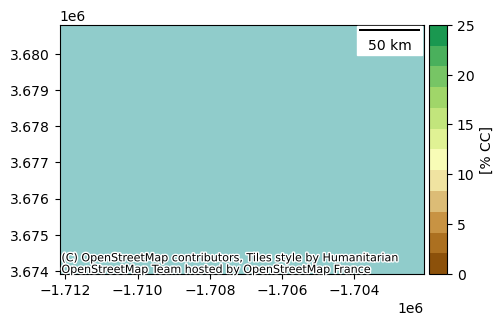

In [23]:
fig, axa = plt.subplots(1,1, figsize=(5,5))
# Scalebar doesnt seem correct
scalebar = ScaleBar(30) # <-- each pixel (unit) is 30m
plt.gca().add_artist(scalebar)
plot_from_daac(aws_session=d['AWS_SESSION'], s3_data_url=d['RASTER_LIST'][810], ax=axa, SCALE_FACTOR = 1e-2)

## LVIS CAmera Imagery

In [7]:
# set up a granule search with python-cmr
from cmr import GranuleQuery

# get a sample of 10 granules
search = (
    GranuleQuery(mode="https://cmr.earthdata.nasa.gov/search/")
    .short_name("ABOLVIS1A")
    .bounding_box(-168.75, 50.29, -72.42, 72.4)
)
granules = search.get(10)

In [8]:
granules

[{'producer_granule_id': 'ABOLVIS1A_ABoVE2017_0629_R1802_052752.JPG',
  'time_start': '2017-06-29T14:39:12.000Z',
  'updated': '2019-03-25T08:58:06.343Z',
  'dataset_id': 'ABoVE LVIS L1A Geotagged Images V001',
  'points': ['52.170744 -106.68444'],
  'data_center': 'NSIDC_CPRD',
  'title': 'ABOLVIS1A_ABoVE2017_0629_R1802_052752.JPG',
  'coordinate_system': 'GEODETIC',
  'day_night_flag': 'UNSPECIFIED',
  'time_end': '2017-06-29T14:39:12.000Z',
  'id': 'G3156415532-NSIDC_CPRD',
  'original_format': 'ECHO10',
  'granule_size': '6.57728',
  'browse_flag': False,
  'collection_concept_id': 'C3151645377-NSIDC_CPRD',
  'online_access_flag': True,
  'links': [{'rel': 'http://esipfed.org/ns/fedsearch/1.1/data#',
    'title': 'Download ABOLVIS1A_ABoVE2017_0629_R1802_052752.JPG',
    'hreflang': 'en-US',
    'href': 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/LVIS/ABOLVIS1A/1/2017/06/29/ABOLVIS1A_ABoVE2017_0629_R1802_052752.JPG'},
   {'rel': 'http://esipfed.org/ns/fe